In [9]:
from koala.pointsets import uniform
from koala import graph_utils as gu
from koala import plotting as pl
from koala.voronization import generate_lattice
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.lattice import Lattice
from scipy import linalg as la
from pfapack.pfaffian import pfaffian

from koala.graph_color import vertex_color
from koala import example_graphs as eg
from dimer_models.koala_plantri import plantri_to_koala, plantri_generator, read_plantri
from dimer_models.lattice_generation import (
    bipartite_squarefull,
    reduce_bipartite,
)

from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    find_kasteleyn_number,
    find_local_dimer_probability,
)

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from copy import copy

In [10]:
def random_flip_mask(lattice, n_plaqs):
    mask = np.zeros(lattice.n_edges)
    for j in range(n_plaqs):
        found = False
        while not found:
            plaq_suggestion = np.random.randint(lattice.n_plaquettes)
            plaq = lattice.plaquettes[plaq_suggestion]
            p_edges = plaq.edges
            choice_1 = p_edges[::2]
            choice_2 = p_edges[1::2]

            exterior = np.array(
                [lattice.vertices.adjacent_edges[x] for x in plaq.vertices]
            ).flatten()
            exterior = np.setxor1d(exterior, plaq.edges)

            if not np.all(mask[exterior] == 0):
                continue

            poss_1 = np.all(mask[choice_1] == 0)
            poss_2 = np.all(mask[choice_2] == 0)

            if poss_1:
                found = True
                mask[choice_2] = 1 - mask[choice_2]
            elif poss_2:
                found = True
                mask[choice_1] = 1 - mask[choice_1]
    return mask

0.2198537849569982 0.4919108410602599


<Axes: >

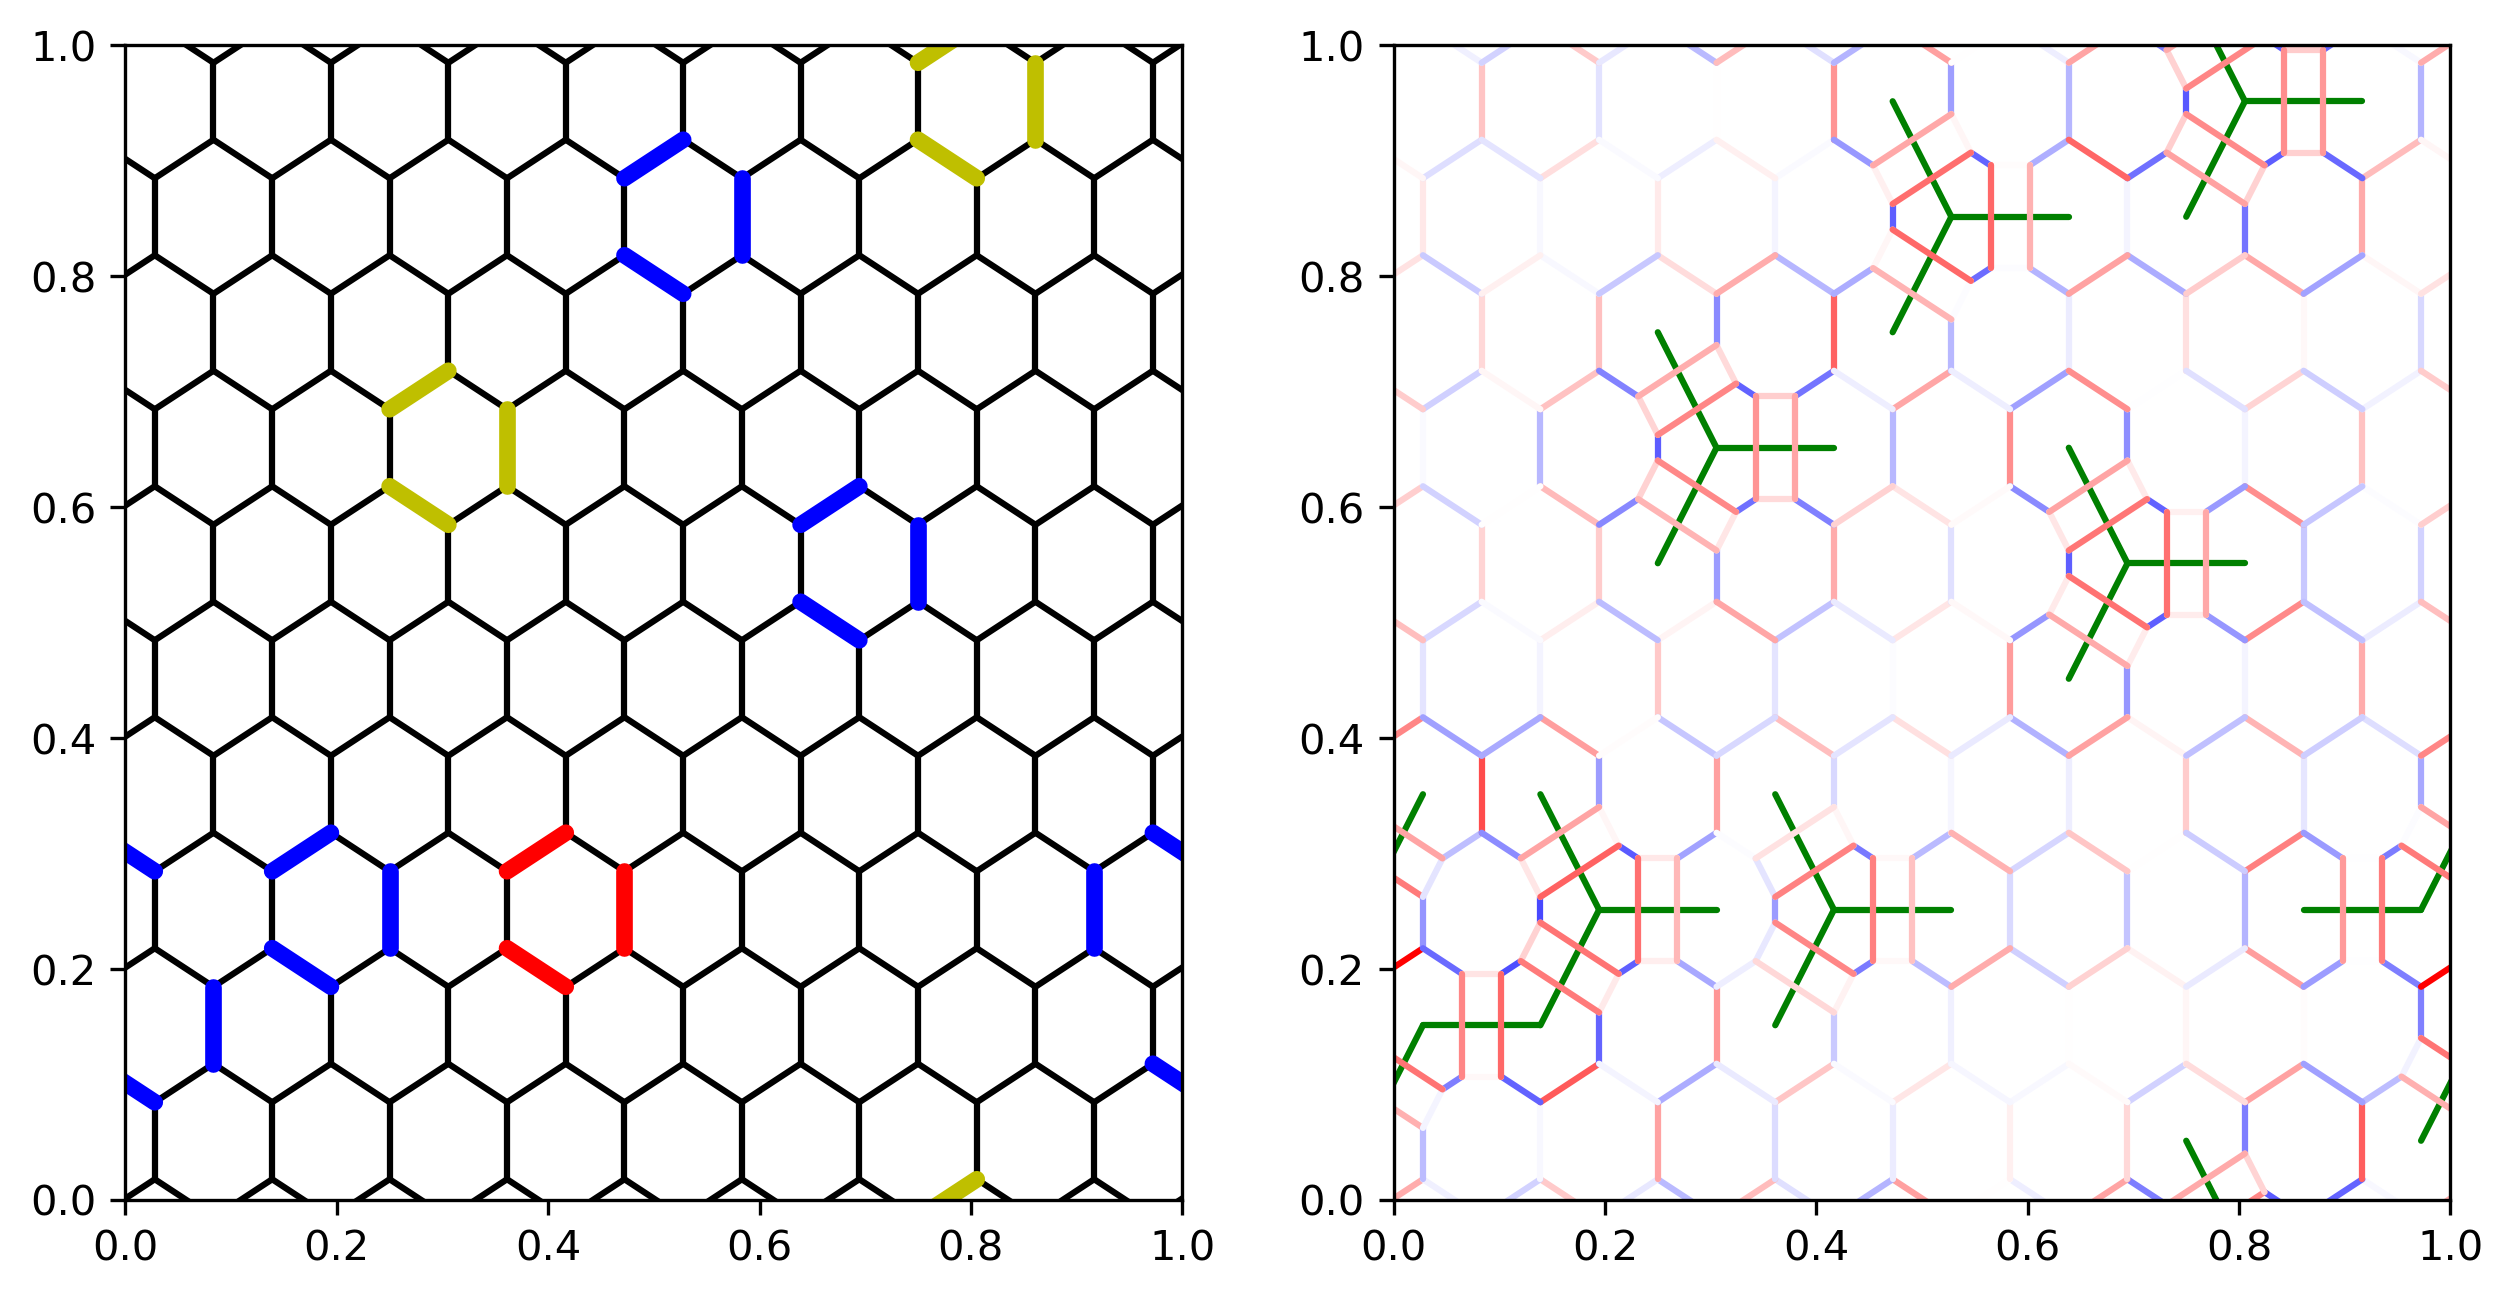

In [ ]:
n = 9
window = 0.3

center = 0.5 + 1 / (4 * n)
lattice = eg.honeycomb_lattice(n)
edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

# # kitaev edge labels
# edge_angles = (
#     np.arctan2(lattice.edges.vectors[:, 1], lattice.edges.vectors[:, 0]) % np.pi
# )
# _, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

# kekule edge labels
dual = gu.make_dual(lattice, reg_steps=0)
plaq_labels = vertex_color(dual.edges.indices, 3)[1]
kekule_labels = plaq_labels[lattice.edges.adjacent_plaquettes].sum(axis=1) - 1

mask = random_flip_mask(lattice, 10)
l2 = expand_edges_to_squares(lattice, np.where(mask)[0])


fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=300)
pl.plot_edges(
    lattice,
    ax=ax[0],
    # labels=kekule_labels,
    # color_scheme=["r", "y", "b"],
)
pl.plot_edges(
    lattice,
    labels=kekule_labels,
    color_scheme=["r", "y", "b"],
    subset=np.where(mask),
    ax=ax[0],
    linewidth=4,
)

probs = find_local_dimer_probability(l2) - (1 / 3)
print(min(probs + 1 / 3), max(probs + 1 / 3))
probs = 0.5 * probs / np.max(np.abs(probs))  # Normalize to range [-1, 1]


edge_labels = np.arange(l2.n_edges)
cmap = plt.get_cmap("bwr")
color_scheme = cmap(probs + 0.5)  # Shift to center around 0

pl.plot_edges(
    l2,
    ax=ax[1],
    labels=edge_labels,
    color_scheme=color_scheme,
    # linewidth=3,
)

pl.plot_edges(
    dual, subset=np.where(mask)[0], ax=ax[1], color_scheme=["g", "y"], zorder=-10
)
# pl.plot_edges(l2, ax=ax[1], linewidth=2)